# Step 1: Load the Data and Take a Quick Look

In [2]:
import pandas as pd

# load the IBM HR Analytics dataset
df= pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# display the first 5 rows of the dataset
df.head
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# Step 2: Exploratory Data Analysis (EDA) & Checking for Missing Values
* Before we feed this data into a machine learning model, we need to do a quick health check on the data. We need to:

* Check if there are any missing values (NaNs).
* Look at the data types (objects are text/categorical, int64 are numbers).
* Check the balance of our target variable (Attrition) to see how many "Yes" vs "No" we have.

In [3]:
# check datatype and missing values
print("=====Dataset info=====")
df.info()

#check how many missing values we have in total 
print("\n--- Total Missing Values ---")
print(df.isnull().sum())
print("\n--- Total Missing Values ---")
print(df.isnull().sum().sum())

# distribution of target variable( Attrition)

print("\n--- Target Variable Distribution ---")

print(df['Attrition'].value_counts())

print(df[['EmployeeCount', 'StandardHours', 'Over18']].nunique())
print("EmployeeNumber unique values:", df['EmployeeNumber'].nunique(), "vs total rows:", len(df))


=====Dataset info=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  J

# Step 3: Data Preprocessing & Encoding



In [4]:
# 1. Drop useless columns
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=columns_to_drop)

# 2. Convert target variable 'Attrition' to binary (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Separate features and target — no encoding yet, that happens inside the Pipeline
X = df.drop('Attrition', axis=1)
y = df['Attrition']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("X shape:", X.shape)

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
X shape: (1470, 30)


# Step 4: Train-Test Split
* stratify=y — your target is 84/16 imbalanced, so without stratification your train/test split could randomly end up with a worse ratio than the full dataset. This is a small addition that a reviewer would specifically check for.
handle_unknown='ignore' on the encoder is what replaces your old reindex(fill_value=0) — if the Streamlit app ever gets a category it hasn't seen, it's handled cleanly instead of crashing or silently misaligning.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Split BEFORE any encoding/scaling — prevents data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Attrition rate in train:", y_train.mean().round(3))
print("Attrition rate in test:", y_test.mean().round(3))

# 2. Build the preprocessing step — fit only on training data (fitting happens later, in the pipeline)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ],
    remainder='passthrough'  # numeric columns pass through unchanged
)

print("\nPreprocessor defined. Categorical cols:", len(categorical_cols), "| Numeric cols:", len(numeric_cols))

X_train shape: (1176, 30)
X_test shape: (294, 30)
Attrition rate in train: 0.162
Attrition rate in test: 0.16

Preprocessor defined. Categorical cols: 7 | Numeric cols: 23


# EDA

/tmp/ipykernel_58/298264293.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Stay', 'Leave'])


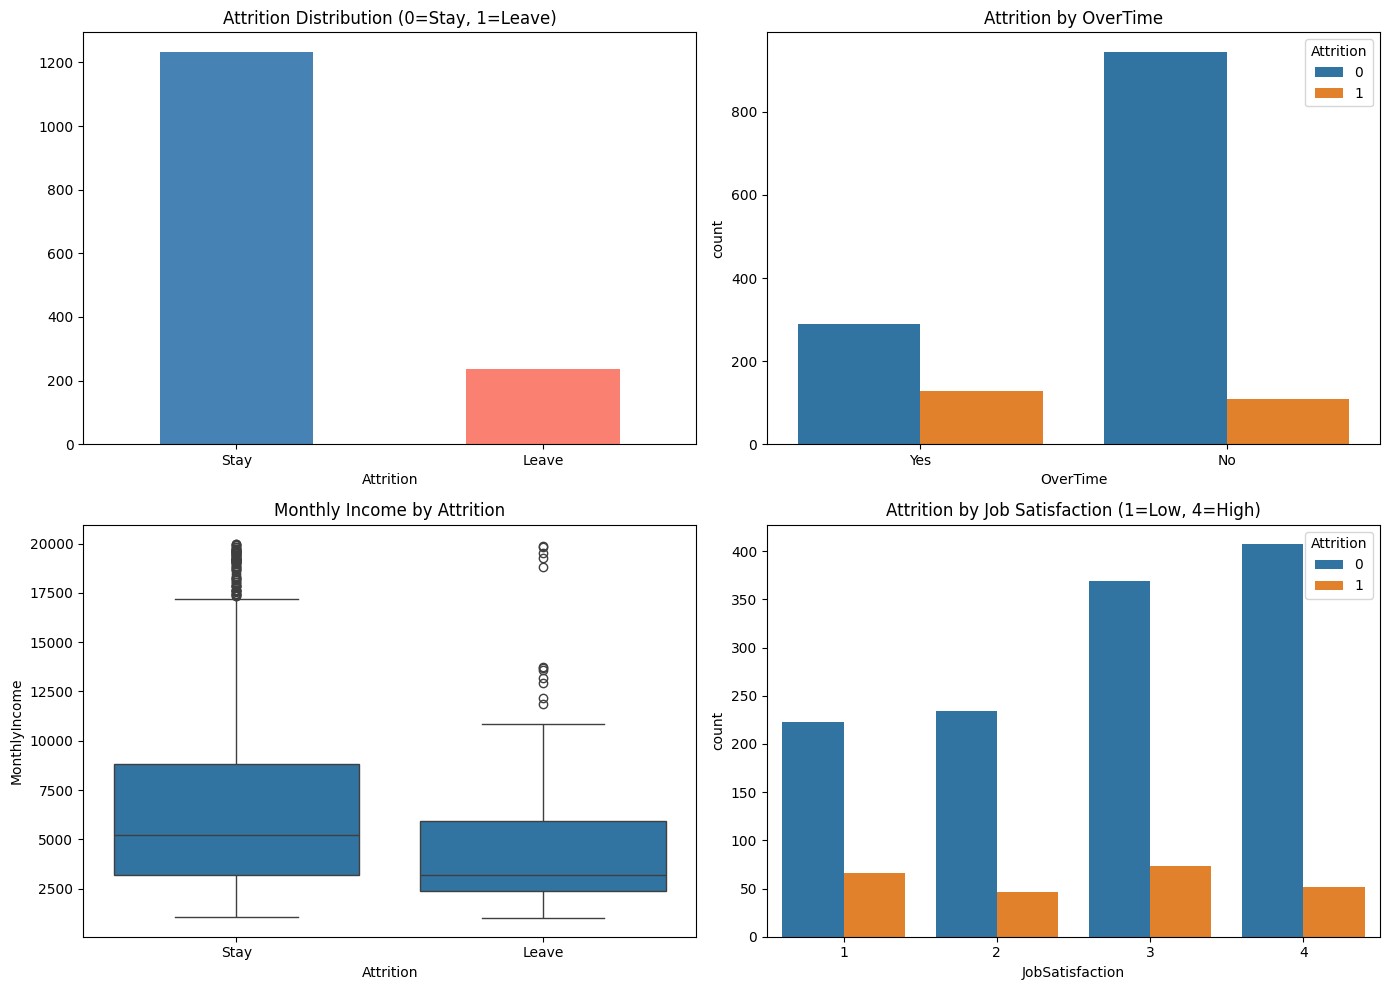

Correlations with Attrition (full, sorted):
TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Attrition                   1.000000
Name: Attrition, dtype: float64


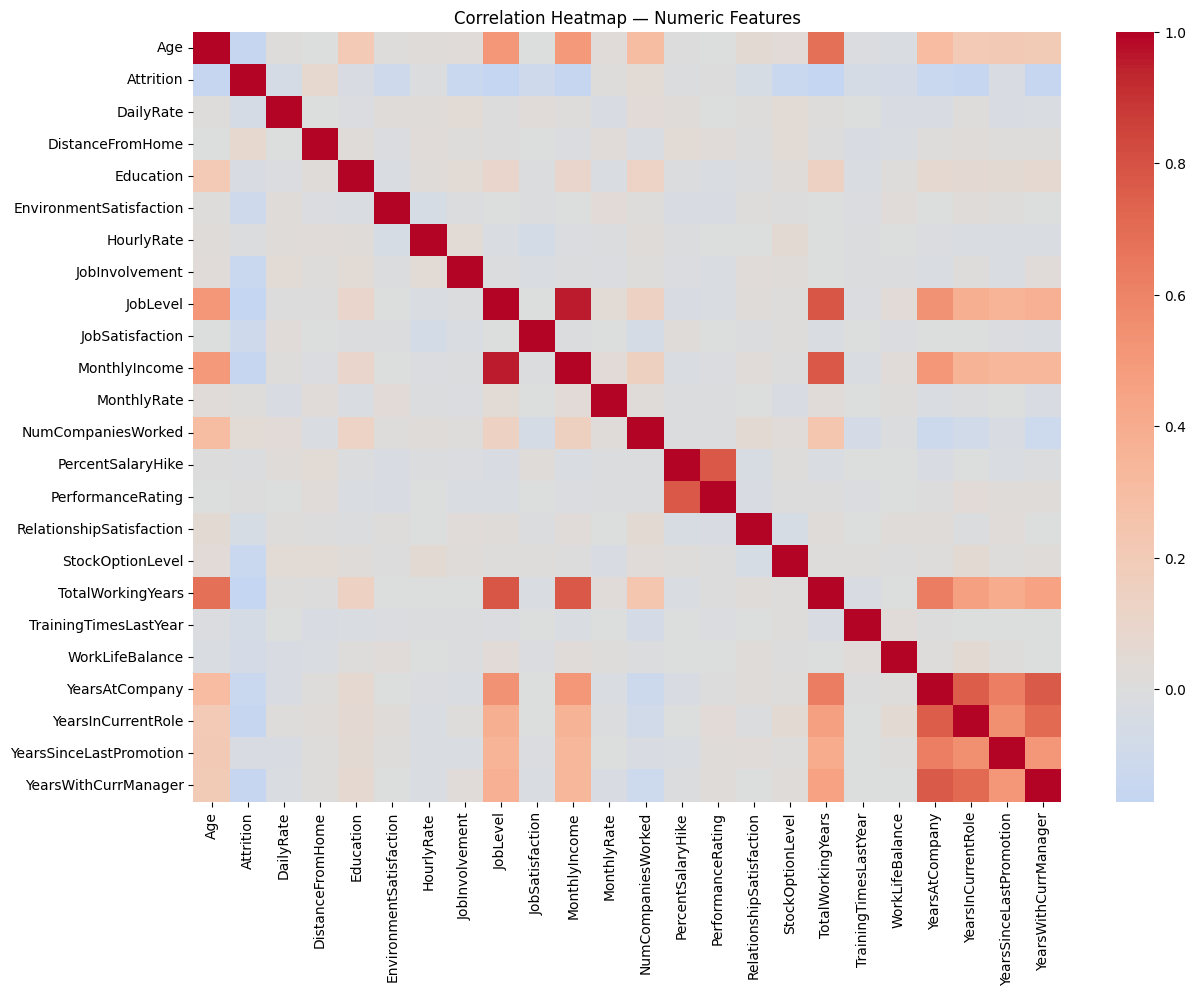

Top correlations with Attrition:
Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
Name: Attrition, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target distribution
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue', 'salmon'])
axes[0,0].set_title('Attrition Distribution (0=Stay, 1=Leave)')
axes[0,0].set_xticklabels(['Stay', 'Leave'], rotation=0)

# 2. OverTime vs Attrition
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0,1])
axes[0,1].set_title('Attrition by OverTime')

# 3. MonthlyIncome distribution by Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1,0])
axes[1,0].set_xticklabels(['Stay', 'Leave'])
axes[1,0].set_title('Monthly Income by Attrition')

# 4. JobSatisfaction vs Attrition
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1,1])
axes[1,1].set_title('Attrition by Job Satisfaction (1=Low, 4=High)')

plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features (including target)
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(exclude='object')
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap — Numeric Features')
print("Correlations with Attrition (full, sorted):")
print(numeric_df.corr()['Attrition'].sort_values())
plt.show()

# What actually correlates with Attrition, ranked
print("Top correlations with Attrition:")
print(numeric_df.corr()['Attrition'].sort_values(ascending=False).head(10))

# pipeline + SMOTE + cross-validation + test evaluation

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

# 1. Full pipeline: preprocessing -> SMOTE (train-only) -> Random Forest
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. 5-fold cross-validation on the training set only (more honest than a single split)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='f1')
cv_recall_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='recall')

print(f"5-Fold CV F1 (Leave class): {cv_f1_scores.mean():.3f} ± {cv_f1_scores.std():.3f}")
print(f"5-Fold CV Recall (Leave class): {cv_recall_scores.mean():.3f} ± {cv_recall_scores.std():.3f}")

# 3. Fit on the full training set
model_pipeline.fit(X_train, y_train)

# 4. Evaluate on the held-out test set — both hard predictions and probabilities
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]  # probability of "Leave"

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

5-Fold CV F1 (Leave class): 0.383 ± 0.140
5-Fold CV Recall (Leave class): 0.263 ± 0.114

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63       294
weighted avg       0.84      0.86      0.83       294

ROC-AUC: 0.775


# precision-recall tradeoff

In [8]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get precision/recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find the threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores[:-1].argmax()  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold for F1: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# Also show what a recall-prioritized threshold looks like (e.g. 0.3 cutoff)
for t in [0.5, 0.4, 0.3, best_threshold]:
    y_pred_t = (y_pred_proba >= t).astype(int)
    print(f"\nThreshold {t:.2f}:")
    print(classification_report(y_test, y_pred_t, digits=2))

Best threshold for F1: 0.300
At this threshold -> Precision: 0.429, Recall: 0.574, F1: 0.491

Threshold 0.50:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.69      0.23      0.35        47

    accuracy                           0.86       294
   macro avg       0.78      0.61      0.64       294
weighted avg       0.84      0.86      0.83       294


Threshold 0.40:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.45      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.62       294
weighted avg       0.80      0.83      0.81       294


Threshold 0.30:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       247
           1       0.43      0.57      0.49        47

    accuracy                          

In [9]:
DECISION_THRESHOLD = 0.30
print(f"Using decision threshold: {DECISION_THRESHOLD}")

# Confirm final numbers at the chosen threshold
y_pred_final = (y_pred_proba >= DECISION_THRESHOLD).astype(int)
print(classification_report(y_test, y_pred_final))

Using decision threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       247
           1       0.43      0.57      0.49        47

    accuracy                           0.81       294
   macro avg       0.67      0.71      0.69       294
weighted avg       0.84      0.81      0.82       294



# extract feature importance

Top 15 Most Important Features:
OverTime_Yes                         0.098224
MaritalStatus_Single                 0.087466
StockOptionLevel                     0.060213
MaritalStatus_Married                0.044261
MonthlyIncome                        0.039481
JobSatisfaction                      0.032247
YearsWithCurrManager                 0.029292
BusinessTravel_Travel_Frequently     0.029174
Age                                  0.028868
TotalWorkingYears                    0.028407
JobInvolvement                       0.027987
Department_Research & Development    0.027394
NumCompaniesWorked                   0.026576
EnvironmentSatisfaction              0.026558
JobRole_Laboratory Technician        0.025945
dtype: float64


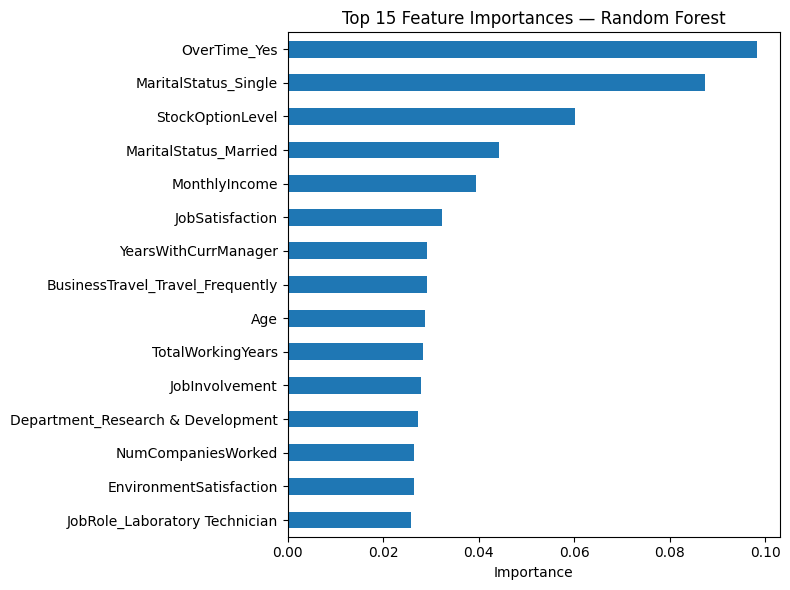

In [10]:
import pandas as pd

# 1. Get the fitted OneHotEncoder's generated column names
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

# 2. Numeric columns pass through unchanged, in their original order
all_feature_names = list(cat_feature_names) + numeric_cols

# 3. Pull importances from the trained RandomForest inside the pipeline
importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_importance = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# 4. Quick horizontal bar chart — useful for both README and the Streamlit app later
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
feature_importance.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# SHAP

Shape check — should match (n_test_samples, n_features): (294, 44)
X_test_transformed shape: (294, 44)


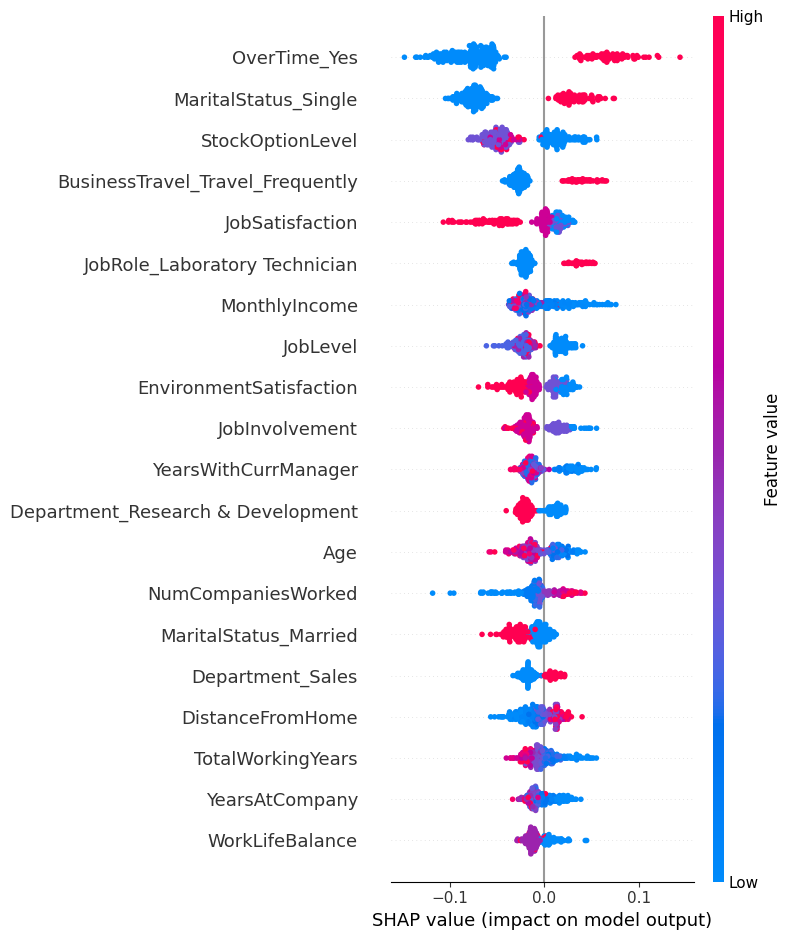

In [11]:
import shap
import numpy as np
import matplotlib.pyplot as plt

X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(model_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Handle both SHAP API versions correctly
if isinstance(shap_values, list):
    shap_values_leave = shap_values[1]          # older API: list of arrays per class
elif shap_values.ndim == 3:
    shap_values_leave = shap_values[:, :, 1]    # newer API: (samples, features, classes)
else:
    shap_values_leave = shap_values             # already 2D

print("Shape check — should match (n_test_samples, n_features):", shap_values_leave.shape)
print("X_test_transformed shape:", X_test_transformed.shape)

shap.summary_plot(shap_values_leave, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

# per-employee explanation function

Highest-risk employee in test set (index 92):



Employee (test set index 92)
Predicted attrition risk: 82.0%
Actual outcome: Left



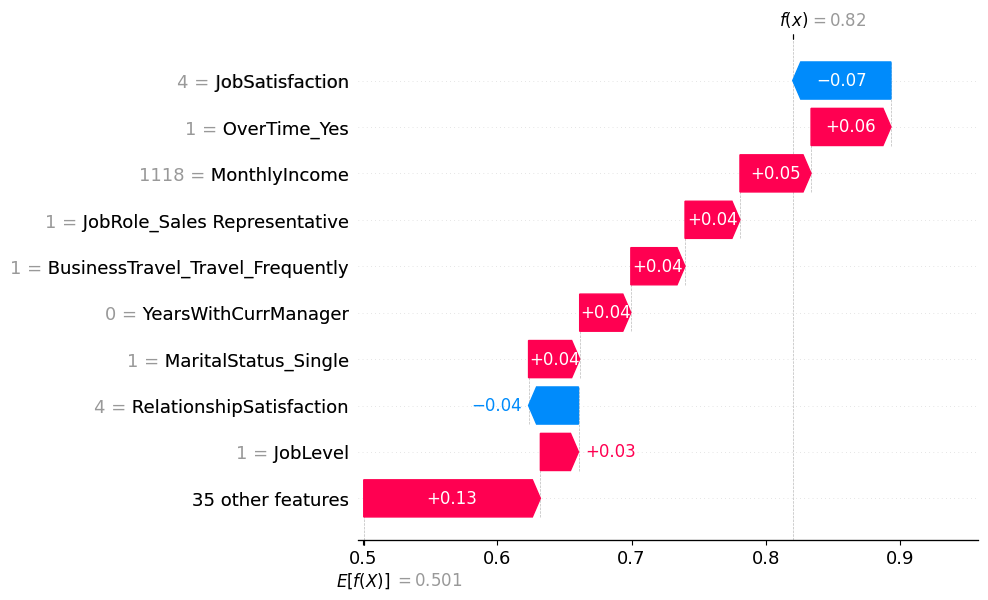

In [12]:
def explain_employee(index_in_test_set):
    """Show SHAP explanation for a single employee in X_test."""
    shap.initjs()
    
    employee_data = X_test.iloc[index_in_test_set]
    risk_prob = y_pred_proba[index_in_test_set]
    
    print(f"Employee (test set index {index_in_test_set})")
    print(f"Predicted attrition risk: {risk_prob:.1%}")
    print(f"Actual outcome: {'Left' if y_test.iloc[index_in_test_set] == 1 else 'Stayed'}")
    print()
    
    # Waterfall plot — shows how each feature pushed this specific prediction
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_leave[index_in_test_set],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
            data=X_test_transformed[index_in_test_set],
            feature_names=all_feature_names
        ),
        max_display=10
    )

# Try it on a high-risk employee
high_risk_idx = np.argmax(y_pred_proba)
print(f"Highest-risk employee in test set (index {high_risk_idx}):\n")
explain_employee(high_risk_idx)

In [13]:
def predict_employee_risk(employee_dict, top_n=5):
    """
    Takes a raw employee dict (same format as the training features),
    returns risk probability, risk label, and top contributing factors.
    """
    emp_df = pd.DataFrame([employee_dict])
    
    # Predict probability using the full pipeline
    risk_prob = model_pipeline.predict_proba(emp_df)[0, 1]
    risk_label = "High Risk" if risk_prob >= DECISION_THRESHOLD else "Low Risk"
    
    # SHAP explanation — transform through the same preprocessor
    emp_transformed = model_pipeline.named_steps['preprocessor'].transform(emp_df)
    emp_shap = explainer.shap_values(emp_transformed)
    emp_shap_leave = emp_shap[:, :, 1] if (not isinstance(emp_shap, list) and emp_shap.ndim == 3) else (emp_shap[1] if isinstance(emp_shap, list) else emp_shap)
    
    shap_series = pd.Series(emp_shap_leave[0], index=all_feature_names).sort_values(key=abs, ascending=False)
    top_factors = shap_series.head(top_n)
    
    return {
        'risk_probability': round(risk_prob, 3),
        'risk_label': risk_label,
        'top_factors': top_factors
    }

# Test it on a sample employee using the SAME raw feature format as X (not one-hot encoded)
test_employee = X_test.iloc[high_risk_idx].to_dict()
result = predict_employee_risk(test_employee)
print(f"Risk: {result['risk_probability']:.1%} ({result['risk_label']})")
print("\nTop contributing factors (SHAP value, sign shows direction):")
print(result['top_factors'])

Risk: 82.0% (High Risk)

Top contributing factors (SHAP value, sign shows direction):
JobSatisfaction                    -0.073129
OverTime_Yes                        0.059484
MonthlyIncome                       0.052934
JobRole_Sales Representative        0.040904
BusinessTravel_Travel_Frequently    0.040346
dtype: float64


# DEploy

In [14]:
import joblib

# 1. The full pipeline (preprocessing + SMOTE + model) — this alone replaces
#    the old attrition_model.pkl + model_columns.pkl + manual encoding in app.py
joblib.dump(model_pipeline, 'attrition_pipeline.pkl')

# 2. The SHAP explainer, so the app doesn't need to rebuild it from scratch
joblib.dump(explainer, 'shap_explainer.pkl')

# 3. Feature names (needed to label SHAP values in the app) and the decision threshold
joblib.dump(all_feature_names, 'feature_names.pkl')
joblib.dump(DECISION_THRESHOLD, 'decision_threshold.pkl')

# 4. Also save the raw feature column names/order + which are categorical vs numeric —
#    the app needs to build a raw input DataFrame in exactly this shape
joblib.dump({'categorical_cols': categorical_cols, 'numeric_cols': numeric_cols, 'all_raw_cols': X.columns.tolist()}, 'feature_metadata.pkl')

print("Saved: attrition_pipeline.pkl, shap_explainer.pkl, feature_names.pkl, decision_threshold.pkl, feature_metadata.pkl")

Saved: attrition_pipeline.pkl, shap_explainer.pkl, feature_names.pkl, decision_threshold.pkl, feature_metadata.pkl


In [15]:
print(df['MonthlyIncome'].describe())
print()
print(df['DistanceFromHome'].describe())
print()
print(df['JobRole'].unique().tolist())
print()
print(df['EducationField'].unique().tolist())
print()
print(df['Department'].unique().tolist())

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: DistanceFromHome, dtype: float64

['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']

['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']

['Sales', 'Research & Development', 'Human Resources']


# model comparison

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, clf in candidates.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', clf)
    ])
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    recall = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall')
    roc_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    results.append({
        'Model': name,
        'F1 (mean ± std)': f"{f1.mean():.3f} ± {f1.std():.3f}",
        'Recall (mean ± std)': f"{recall.mean():.3f} ± {recall.std():.3f}",
        'ROC-AUC (mean ± std)': f"{roc_auc.mean():.3f} ± {roc_auc.std():.3f}"
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

              Model F1 (mean ± std) Recall (mean ± std) ROC-AUC (mean ± std)
Logistic Regression   0.448 ± 0.036       0.679 ± 0.039        0.775 ± 0.017
      Decision Tree   0.339 ± 0.046       0.368 ± 0.076        0.609 ± 0.028
      Random Forest   0.383 ± 0.140       0.263 ± 0.114        0.816 ± 0.024


# finalize Logistic Regression

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Logistic Regression needs scaled numeric features — both to converge properly
# and so coefficients are actually comparable to each other later
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("Test Set Classification Report (default 0.5 threshold, scaled features):")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores[:-1].argmax()
DECISION_THRESHOLD = round(float(thresholds[best_idx]), 2)

print(f"\nBest threshold for F1: {DECISION_THRESHOLD}")
y_pred_final = (y_pred_proba >= DECISION_THRESHOLD).astype(int)
print(f"\nFinal report at tuned threshold {DECISION_THRESHOLD}:")
print(classification_report(y_test, y_pred_final))

Test Set Classification Report (default 0.5 threshold, scaled features):
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.38      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294

ROC-AUC: 0.796

Best threshold for F1: 0.65

Final report at tuned threshold 0.65:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       247
           1       0.46      0.53      0.50        47

    accuracy                           0.83       294
   macro avg       0.69      0.71      0.70       294
weighted avg       0.84      0.83      0.83       294



# feature importance — for Logistic Regression

Top 15 Features by Coefficient Magnitude:
BusinessTravel_Travel_Frequently    1.885000
JobRole_Research Director          -1.853467
OverTime_Yes                        1.838151
JobRole_Laboratory Technician       1.634162
EducationField_Other               -1.429837
JobRole_Sales Representative        1.260288
BusinessTravel_Travel_Rarely        1.116157
MaritalStatus_Single                0.926361
TotalWorkingYears                  -0.915129
EducationField_Life Sciences       -0.684007
JobRole_Manager                    -0.649602
EducationField_Marketing           -0.601068
Department_Sales                    0.538000
YearsWithCurrManager               -0.523410
NumCompaniesWorked                  0.509894
dtype: float64


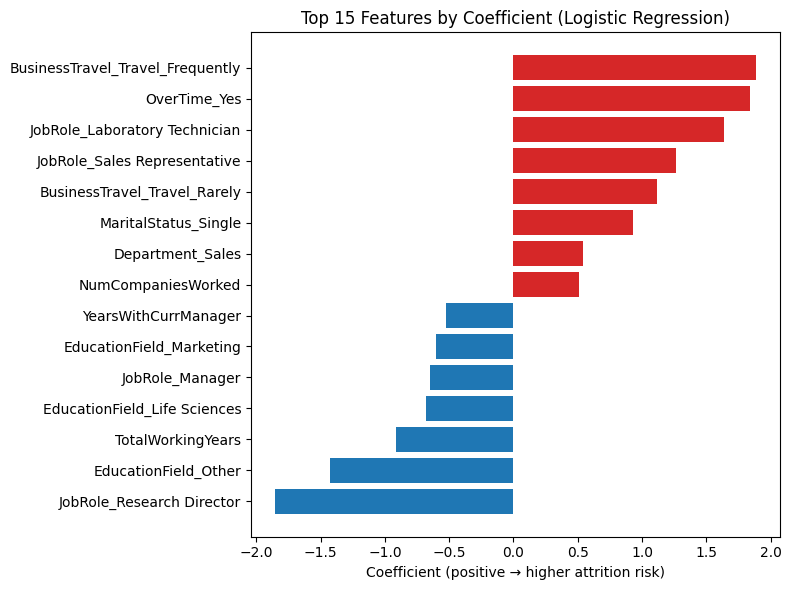

In [19]:
import pandas as pd

# Get feature names from the fitted encoder (same as before)
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(cat_feature_names) + numeric_cols

# Logistic Regression coefficients — sign shows direction, magnitude shows strength
# (valid to compare magnitudes now because numeric features are scaled)
coefficients = model_pipeline.named_steps['classifier'].coef_[0]

feature_importance = pd.Series(coefficients, index=all_feature_names).sort_values(key=abs, ascending=False)

print("Top 15 Features by Coefficient Magnitude:")
print(feature_importance.head(15))

import matplotlib.pyplot as plt

top15 = feature_importance.head(15).sort_values()
colors = ['#d62728' if v > 0 else '#1f77b4' for v in top15.values]

plt.figure(figsize=(8, 6))
plt.barh(top15.index, top15.values, color=colors)
plt.title('Top 15 Features by Coefficient (Logistic Regression)')
plt.xlabel('Coefficient (positive → higher attrition risk)')
plt.tight_layout()
plt.show()

**the two models agree OverTime and travel frequency matter a lot, but disagree on how much role/education specifics matter.**

# SHAP — LinearExplainer instead of TreeExplainer

SHAP values shape: (294, 44)
X_test_transformed shape: (294, 44)


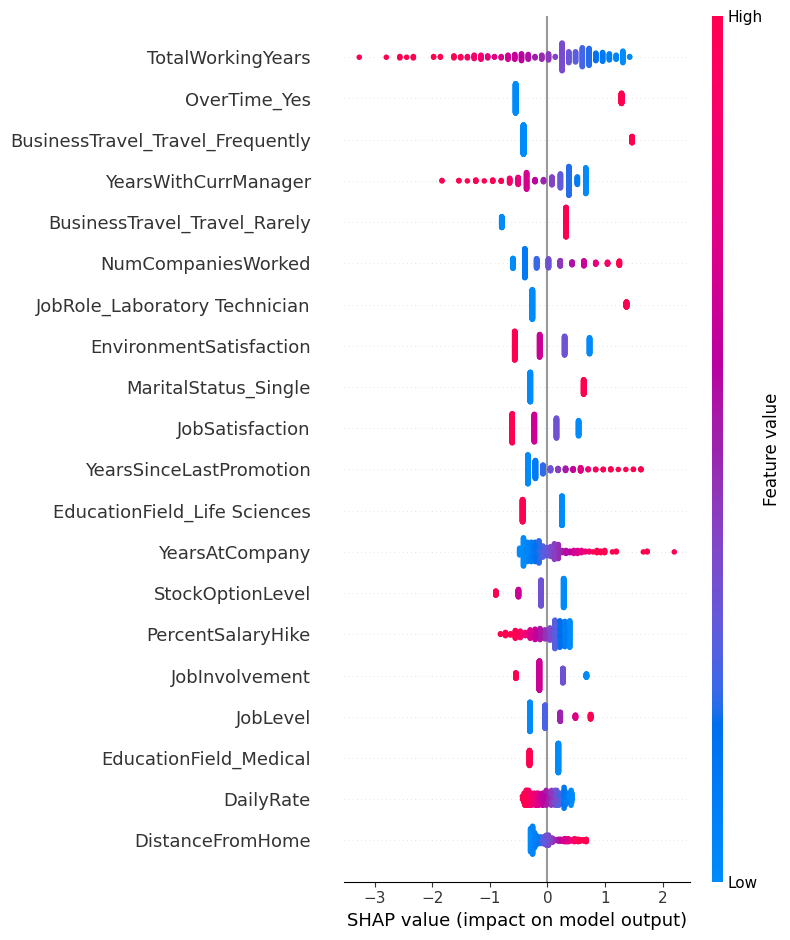

In [20]:
import shap
import matplotlib.pyplot as plt

# LinearExplainer needs a background dataset to account for feature correlations —
# use the transformed TRAINING data, not test data, for that background
X_train_transformed = model_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.LinearExplainer(model_pipeline.named_steps['classifier'], X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)
print("X_test_transformed shape:", X_test_transformed.shape)

shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

# er-employee explanation function

Highest-risk employee in test set (index 214):

Employee (test set index 214)
Predicted attrition risk: 99.4%
Actual outcome: Left



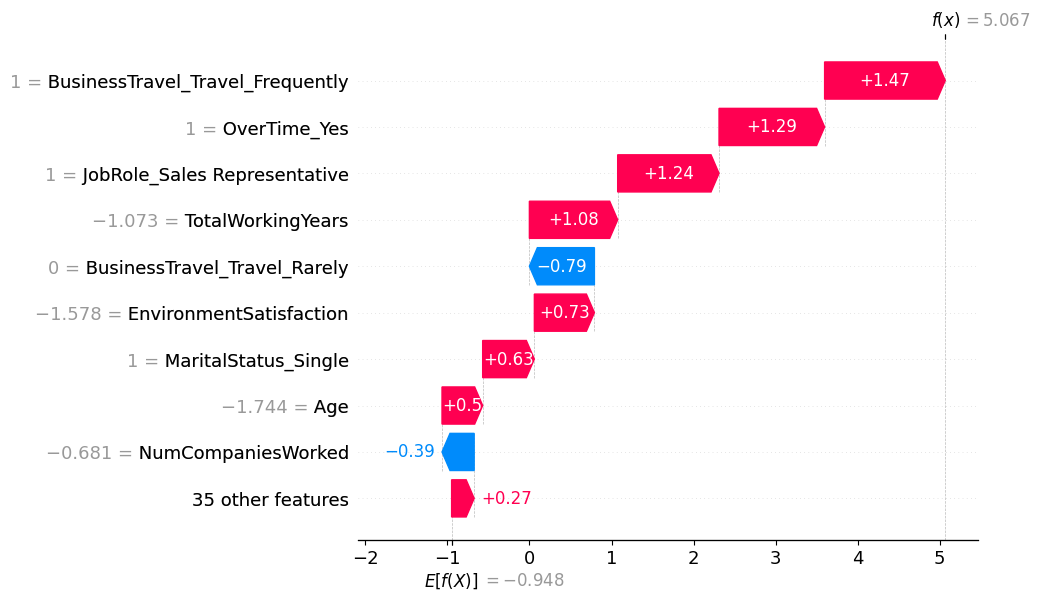

In [21]:
def explain_employee(index_in_test_set):
    """Show SHAP explanation for a single employee in X_test."""
    risk_prob = y_pred_proba[index_in_test_set]

    print(f"Employee (test set index {index_in_test_set})")
    print(f"Predicted attrition risk: {risk_prob:.1%}")
    print(f"Actual outcome: {'Left' if y_test.iloc[index_in_test_set] == 1 else 'Stayed'}")
    print()

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index_in_test_set],
            base_values=explainer.expected_value,
            data=X_test_transformed[index_in_test_set],
            feature_names=all_feature_names
        ),
        max_display=10
    )

high_risk_idx = np.argmax(y_pred_proba)
print(f"Highest-risk employee in test set (index {high_risk_idx}):\n")
explain_employee(high_risk_idx)

In [22]:
import joblib

joblib.dump(model_pipeline, 'attrition_pipeline.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(all_feature_names, 'feature_names.pkl')
joblib.dump(DECISION_THRESHOLD, 'decision_threshold.pkl')  # 0.65
joblib.dump({'categorical_cols': categorical_cols, 'numeric_cols': numeric_cols, 'all_raw_cols': X.columns.tolist()}, 'feature_metadata.pkl')

print(f"Saved all artifacts. Final model: Logistic Regression, threshold: {DECISION_THRESHOLD}")

Saved all artifacts. Final model: Logistic Regression, threshold: 0.65
